<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Exercise.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

# Exercise: Support vector machines and model tuning

© ALX

In this exercise, we will explore the use of `support vector machines` and model tuning techniques using the scikit-learn library. Specifically, we will implement `SVM classifier` models with both linear and radial basis function kernels. We will visualise the decision boundaries created by these models to understand their effectiveness in classifying data points. Additionally, we will utilise hyperparameter tuning with `GridSearchCV` to optimise the SVM model's performance by finding the best combination of hyperparameters.

## Learning Objectives
By the end of this exercise, you should be able to:

* Implement SVM classifier models with linear and RBF kernels using scikit-learn.
* Visualise decision boundaries created by SVM models to assess their effectiveness.
* Understand the importance of hyperparameter tuning and utilise techniques like GridSearchCV to optimise model performance.

Import the libraries that we will need for this exercise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings("ignore")

Generate the data and get training and testing data.

In [2]:
from sklearn.datasets import make_gaussian_quantiles

# Set the feature dimensionality
p = 4

# Construct the dataset
X, y = make_gaussian_quantiles(cov=3.,
                                 n_samples=1000, n_features=p,
                                 n_classes=2, random_state=1)

In [3]:
# get training and testing data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Exercises

### Exercise 1: Fit a SVM classifier with a linear decision boundary
We have a dataset with multiple features, and we want to classify the data into two classes using a support vector machine with a linear decision boundary. By fitting an SVC model with a linear kernel to the training data, we aim to create a decision boundary that separates the classes effectively.

For this exercise, do the following:
* Instantiate an SVC classifier with a linear kernel. 
* Fit the classifier to the training data created above and make predictions on the test data.
* Print the accuracy score and classification report to evaluate the model's performance.

In [4]:
from sklearn.svm import SVC

svc = SVC(kernel='linear', random_state=42)

svc.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [5]:
y_pred = svc.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"\n Accuracy: {accuracy} \n")
print(f"\n Classification Report: \n {classification_rep} \n")


 Accuracy: 0.45666666666666667 


 Classification Report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       163
           1       0.46      1.00      0.63       137

    accuracy                           0.46       300
   macro avg       0.23      0.50      0.31       300
weighted avg       0.21      0.46      0.29       300
 



### Exercise 2: Plot the decision boundary for the SVC
After fitting the SVM classifier with a linear kernel, we observe that the accuracy score was not as high as expected. To gain insights into the model's performance and understand why the accuracy was lower, we decided to visualise the decision boundary. By plotting the decision boundary in a two-dimensional space, we aim to visually inspect how well the linear boundary separates the classes.

For this exercise, do the following:
* Plot the decision boundary for the SVM classifier with a linear kernel.

Based on the visualisation of the decision boundary, what can we infer about the effectiveness of the linear decision boundary in separating the classes?

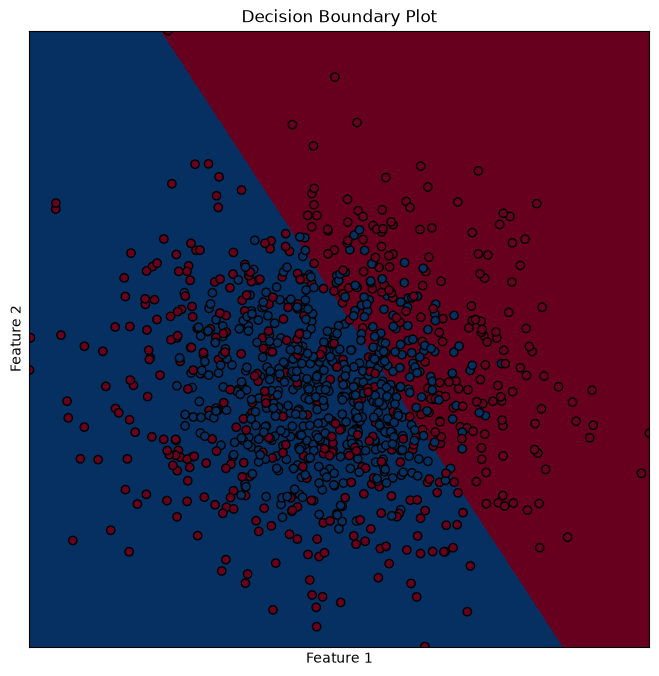

In [ ]:
i = 0 # Feature 1
j = 1 # Feature 2

svc.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)
 
x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap=plt.get_cmap('RdBu_r'))
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap=plt.get_cmap('RdBu_r'))
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Decision Boundary Plot') 
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

### Exercise 3: Fit a SVC classifier with a non-linear decision boundary

Recognising the limitations of the linear decision boundary, fit an SVC model with an RBF kernel to the training data and evaluate its performance on the test set.

For this exercise, do the following:

* Use the provided code to fit an SVC model with an RBF kernel to the training data.
* Make predictions on the test data.
* Print the accuracy score and classification report to evaluate the performance of the model.

Did the use of the RBF kernel improve the accuracy of the SVM classifier compared to the linear kernel? Explain your answer.

In [10]:
from sklearn.svm import SVC

svc_rbf = SVC(kernel='rbf', random_state=42)

svc_rbf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [11]:
y_pred_rbf = svc_rbf.predict(X_test)

In [12]:
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
classification_rep_rbf = classification_report(y_test, y_pred_rbf)

print(f"\n Accuracy (RBF Kernel): {accuracy_rbf} \n")
print(f"\n Classification Report (RBF Kernel): \n {classification_rep_rbf} \n")


 Accuracy (RBF Kernel): 0.9766666666666667 


 Classification Report (RBF Kernel): 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       163
           1       0.98      0.97      0.97       137

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300
 



### Exercise 4: Plot the decision boundary for the SVC using the non-linear RBF kernel

After observing a significant improvement in accuracy with the RBF kernel, your task is to visualise the decision boundary created by the non-linear RBF kernel in a two-dimensional space.

For this exercise, do the following:

* Plot the decision boundary for the SVM classifier with an RBF kernel.
* Compare the decision boundary visualisation of the RBF kernel with the linear kernel.
* Make observations about the differences between the two visualisations.

What differences do you observe, and how do these differences relate to the classification accuracy?

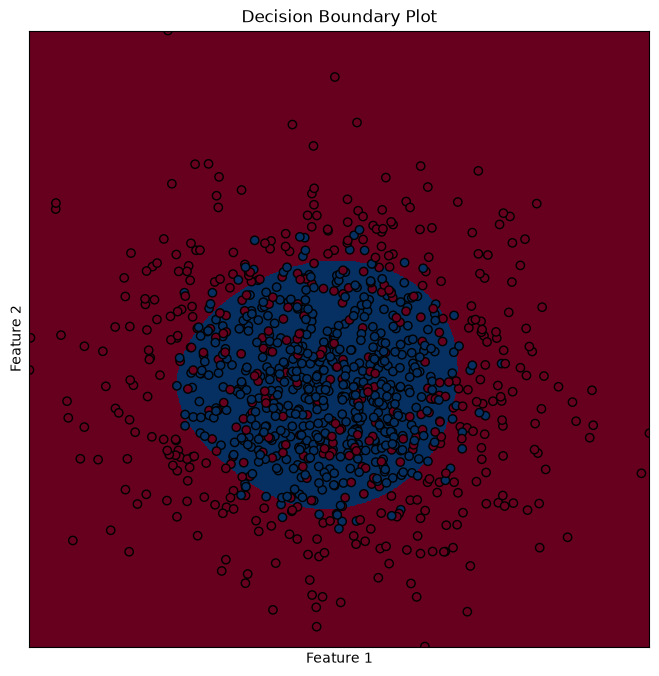

In [13]:
i = 0 # Feature 1
j = 1 # Feature 2

svc_rbf.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)
 
x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc_rbf.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap=plt.get_cmap('RdBu_r'))
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap=plt.get_cmap('RdBu_r'))
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Decision Boundary Plot') 
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

### Exercise 5: Tuning an SVM model

To further optimise the SVM model's performance, utilise hyperparameter tuning using GridSearchCV. Perform a grid search to find the best combination of hyperparameters that maximises model accuracy on the test data.

For this exercise, do the following:

* Define a parameter grid containing different values for the kernel, C, and gamma parameters.
* Instantiate an SVC classifier.
* Perform a grid search using GridSearchCV with the defined parameter grid.
* Fit the grid search object to the training data.
* Make predictions on the test data using the best-tuned model obtained from the grid search.
* Print the accuracy score to evaluate the performance of the tuned model.

What is the purpose of hyperparameter tuning using techniques like GridSearchCV, and how does it help improve the performance of the SVM model?

In [14]:
param_grid = {'C': [0.1, 1, 10, 100], 
              'gamma': [0.001, 0.01, 0.1, 1],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

svc = SVC(random_state=42)

clf = GridSearchCV(svc, param_grid, cv=5)

clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf', 'linear', ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity 

In [15]:
y_pred_clf = clf.predict(X_test)

In [16]:
accuracy_clf = accuracy_score(y_test, y_pred_clf)
classification_rep_clf = classification_report(y_test, y_pred_clf)

print(f"\n Accuracy (Grid Search): {accuracy_clf} \n")
print(f"\n Classification Report (Grid Search): \n {classification_rep_clf} \n")


 Accuracy (Grid Search): 0.9833333333333333 


 Classification Report (Grid Search): 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       163
           1       1.00      0.96      0.98       137

    accuracy                           0.98       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300
 



In [17]:
clf.best_params_

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

## Solutions

### Exercise 1: Fit a SVM classifier with a linear decision boundary

In [19]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

print("The accuracy score of the SVC is:", accuracy_score(y_test, y_pred))
print("\n\nClassification Report:\n\n", classification_report(y_test, y_pred))

The accuracy score of the SVC is: 0.45666666666666667


Classification Report:

               precision    recall  f1-score   support

           0       0.00      0.00      0.00       163
           1       0.46      1.00      0.63       137

    accuracy                           0.46       300
   macro avg       0.23      0.50      0.31       300
weighted avg       0.21      0.46      0.29       300



### Exercise 2: Plot the decision boundary for the SVC

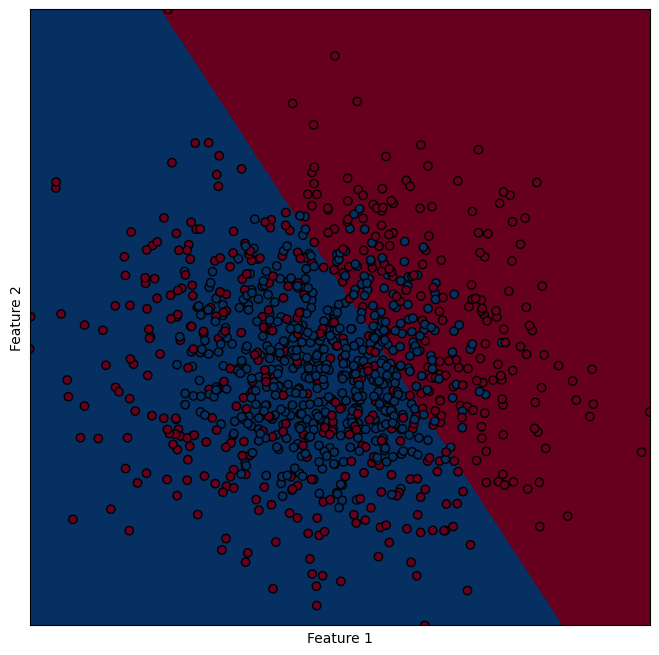

In [20]:
i = 0 # Feature 1
j = 1 # Feature 2

svc.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)
 
x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap=plt.cm.get_cmap('RdBu_r'))
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap=plt.cm.get_cmap('RdBu_r'))
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

Based on the visualisation of the decision boundary, we can infer that the linear decision boundary is not effective in separating the classes. The decision boundary appears to be a straight line, which fails to adequately separate the data points of the two classes. As a result, the linear boundary does not capture the underlying structure of the data well, leading to poor classification performance. Therefore, based on the visualisation, we can conclude that the linear decision boundary is not suitable for this dataset and may require a more complex boundary, such as a non-linear boundary, to improve classification performance.

### Exercise 3: Fit a SVC classifier with a non-linear decision boundary

In [21]:
svc = SVC(kernel='rbf')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

print("The accuracy score of the SVC is:", accuracy_score(y_test, y_pred))
print("\n\nClassification Report:\n\n",classification_report(y_test, y_pred))

The accuracy score of the SVC is: 0.9766666666666667


Classification Report:

               precision    recall  f1-score   support

           0       0.98      0.98      0.98       163
           1       0.98      0.97      0.97       137

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300




The use of the RBF kernel significantly improved the accuracy of the SVM classifier compared to the linear kernel. The accuracy score of the SVM classifier with the RBF kernel is 0.976, whereas in Exercise 1, the accuracy score of the SVM classifier with the linear kernel was only 0.457. This substantial increase in accuracy suggests that the RBF kernel better captures the non-linear relationships within the data, allowing the SVM model to create a more flexible decision boundary. As a result, the RBF kernel achieves higher precision, recall, and F1-score for both classes, indicating better overall performance in classifying the data points.

### Exercise 4: Plot the decision boundary for the SVC using the non-linear RBF kernel

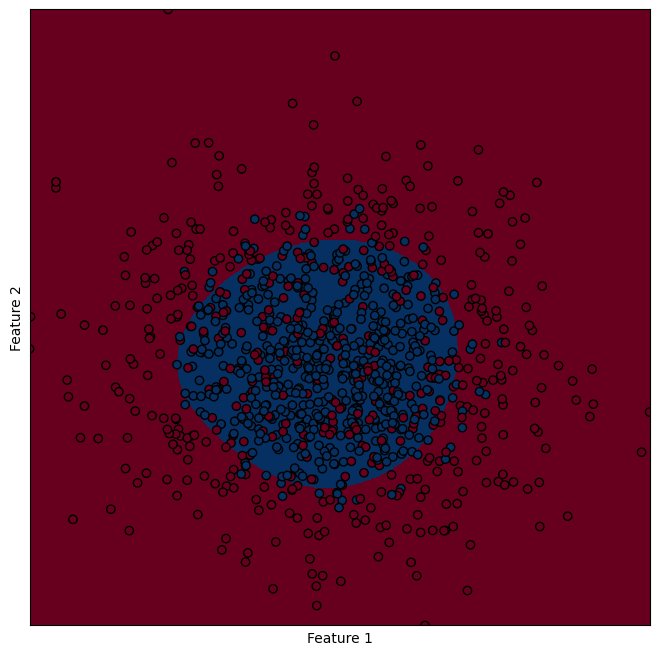

In [22]:
i = 0 # Feature 1
j = 1 # Feature 2

svc.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)
 
x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap=plt.cm.get_cmap('RdBu_r'))
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap=plt.cm.get_cmap('RdBu_r'))
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

After plotting the decision boundary for the SVC using the non-linear RBF kernel, we observe significant differences compared to the linear kernel boundary visualisation. The decision boundary created by the RBF kernel appears to be more complex and non-linear, effectively capturing the intricate relationships between the data points of different classes. Unlike the linear boundary, which was a straight line, the RBF kernel boundary curves and adapts to the shape of the data clusters, resulting in better separation between classes.

### Exercise 5: Tuning an SVM model

In [23]:
parameters = {'kernel':('linear', 'rbf'), 
              'C':(0.25,1.0),
              'gamma': (1,2)}

In [24]:
svm = SVC()
clf = GridSearchCV(svm, parameters)
clf.fit(X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': (0.25, 1.0), 'gamma': (1, 2),
                         'kernel': ('linear', 'rbf')})

In [25]:
y_opt = clf.predict(X_test)
print("The accuracy for our tuned model is: ", accuracy_score(y_test, y_opt))

The accuracy for our tuned model is:  0.9233333333333333


Hyperparameter tuning with techniques like GridSearchCV aims to optimise the SVM model's performance by finding the best combination of hyperparameters. GridSearchCV systematically searches through a predefined grid of hyperparameters and evaluates the model's performance using cross-validation. By selecting the hyperparameter combination that maximises a chosen performance metric, such as accuracy or F1-score, GridSearchCV helps improve the model's accuracy and generalisation ability. Overall, hyperparameter tuning ensures that the SVM model is trained with the most suitable settings for the given dataset, preventing overfitting or underfitting and enhancing its robustness across different datasets and conditions.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/refs/heads/master/ALX_banners/ALX_Navy.png"  style="width:100px";/>
</div>